In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ase.io import read
import ase.units as units
from ase import Atoms
from pathlib import Path

In [21]:
basedir = Path("../pwo")
pwi_list: list[Path] = sorted(basedir.glob("*.out"))

filename: list[str] = [f.name for f in pwi_list]
atoms: list[Atoms] = [read(f) for f in pwi_list] 
energies: list[float]= [atom.get_total_energy() for atom in atoms]
forces: list[np.ndarray] = [atom.get_forces() for atom in atoms]
lattice_a: list[float] = [atom.cell.cellpar()[0] for atom in atoms]
lattice_c: list[float] = [atom.cell.cellpar()[2] for atom in atoms]


In [22]:
data = {
    "filename": filename,
    "a": lattice_a,
    "c": lattice_c,
    "energies": energies,
    "forces": forces,
}
df = pd.DataFrame(data)
df["c/a"] = df.c / df.a

In [23]:
df.sort_values(by="energies")

,filename,a,c,energies,forces,c/a
111,relax_hzno_3.35_4.50.out,3.35,4.500002,-12269.848752,"[[0.0, 0.0, -0.0], [0.0, -0.0, -0.0], [0.0, 0....",1.343284
125,relax_hzno_3.40_4.40.out,3.40,4.400001,-12269.846373,"[[-0.0, -0.0, -4.962229101281777e-05], [0.0, -...",1.294118
110,relax_hzno_3.35_4.40.out,3.35,4.400001,-12269.842174,"[[-0.0, 0.0, -4.8850960064431995e-05], [0.0, -...",1.313433
124,relax_hzno_3.40_4.30.out,3.40,4.300000,-12269.835986,"[[0.0, -0.0, -1.979749434190139e-05], [0.0, 0....",1.264706
112,relax_hzno_3.35_4.60.out,3.35,4.599999,-12269.832153,"[[-0.0, -0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0...",1.373134
...,...,...,...,...,...,...
3,relax_hzno_3.00_4.20.out,3.00,4.200000,-12267.102159,"[[-0.0, -0.0, 2.5711031612858945e-06], [-0.0, ...",1.400000
2,relax_hzno_3.00_4.10.out,3.00,4.100001,-12266.770175,"[[-0.0, -0.0, 1.0027302329014988e-05], [-0.0, ...",1.366667
15,relax_hzno_3.05_3.90.out,3.05,3.900002,-12266.662350,"[[0.0, 0.0, 9.25597138062922e-06], [0.0, 0.0, ...",1.278689
1,relax_hzno_3.00_4.00.out,3.00,3.999999,-12266.355946,"[[0.0, -0.0, 1.1312853909657936e-05], [0.0, 0....",1.333333


In [24]:
df.loc[
df["energies"].idxmin()

]

filename                             relax_hzno_3.35_4.50.out
a                                                        3.35
c                                                    4.500002
energies                                        -12269.848752
forces      [[0.0, 0.0, -0.0], [0.0, -0.0, -0.0], [0.0, 0....
c/a                                                  1.343284
Name: 111, dtype: object

## Contour Plot

In [25]:
from scipy.interpolate import griddata

In [46]:
a_unique = df["a"].unique()
c_unique = df["c"].unique()

A, C = np.meshgrid(a_unique, c_unique)
pontos = df[['a', 'c']].values
valores = df['energies'].values - df["energies"].min()
E_grid = griddata(points=pontos, values=valores, xi=(A, C), method='cubic')


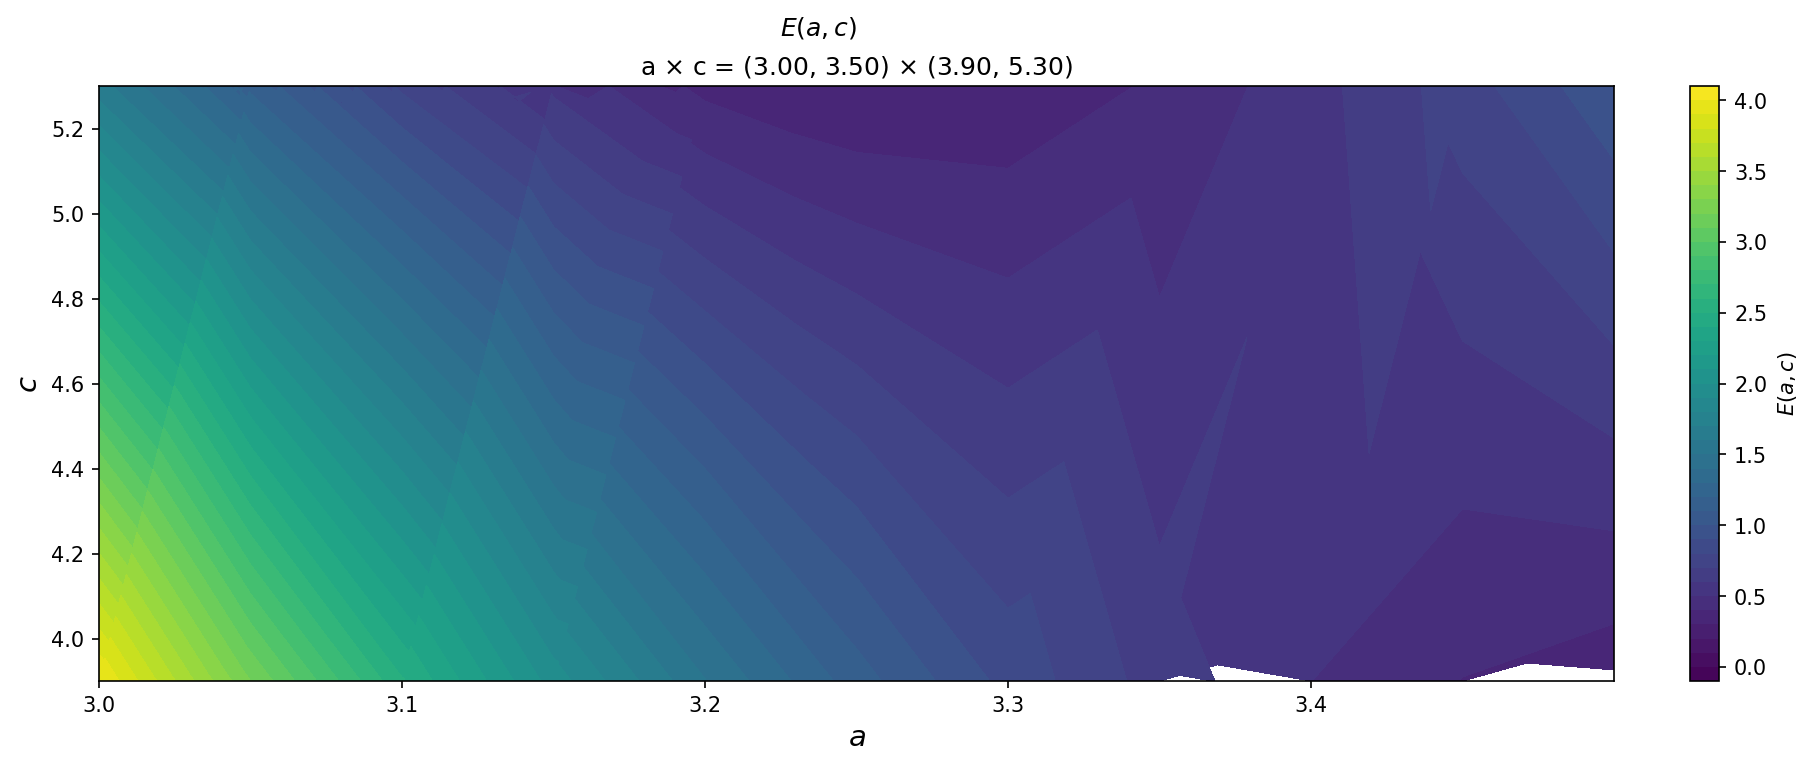

In [47]:
fig, ax = plt.subplots(figsize=(12,5), dpi=150, layout='constrained')
fig.suptitle(r"$E(a,c)$", x=0.45)
ax.set_title(r"a $\times$ c = (3.00, 3.50) $\times$ (3.90, 5.30)")
ax.set_ylabel(r"$c$", size=14)
ax.set_xlabel(r"$a$",size=14)
contour = ax.contourf(A, C, E_grid, levels=40)
cb = plt.colorbar(contour, label="$E(a,c)$")
# contour_lines = ax.contour(A, C, E_grid, levels=20, colors='black', linewidths=.5)



In [ ]:


print("Intervalo de a:", df["a"].min(), df["a"].max())
print("Intervalo de c",df.c.min(), df.c.max())

Intervalo de a: 2.9999997876993123 3.499999752315865
